<a href="https://colab.research.google.com/github/GUSSLURD/Hezekiah/blob/main/Analysis_and_Results_for_Dissertation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 2. Initial Data Loading and Combination

In [ ]:
# Load the separate datasets
conventional_bonds_df = pd.read_excel('/content/Clean Conventional Bond Data.xlsx')
green_bonds_df = pd.read_excel('/content/Clean Green Bond Dataset.xlsx')

# Add an identifier for each type of bond
conventional_bonds_df['is_green_bond'] = 0
green_bonds_df['is_green_bond'] = 1

# Concatenate the two DataFrames
bond_warehouse_df = pd.concat([conventional_bonds_df, green_bonds_df], ignore_index=True)

print("Combined bond_warehouse_df info after loading separate datasets:")
bond_warehouse_df.info()
display(bond_warehouse_df.head())

Combined bond_warehouse_df info after loading separate datasets:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4006 entries, 0 to 4005
Data columns (total 46 columns):
 #   Column                                             Non-Null Count  Dtype 
---  ------                                             --------------  ----- 
 0   Issuer                                             3989 non-null   object
 1   Ticker                                             3989 non-null   object
 2   Coupon                                             3989 non-null   object
 3   Maturity                                           3989 non-null   object
 4   Issue Date                                         3989 non-null   object
 5   ISIN                                               3850 non-null   object
 6   Preferred RIC                                      3422 non-null   object
 7   Principal Currency                                 3989 non-null   object
 8   Country of Issue                 

,Issuer,Ticker,Coupon,Maturity,Issue Date,ISIN,Preferred RIC,Principal Currency,Country of Issue,Issuer Type,...,Unnamed: 36,Unnamed: 37,Moody's Long-term Issue Credit Rating,Unnamed: 39,Additional Fields,is_green_bond,Climate Bonds Initiative,UN Sustainable Development Goals,ESG Bond Type,Coupon Frequency
0,Issuer,Ticker,Coupon,Maturity,Issue Date,ISIN,Preferred RIC,Principal Currency,Country of Issue,Issuer Type,...,Watch,Scope,Rating,Actual,Fitchs Rating,0,NaN,NaN,NaN,NaN
1,SB Capital SA,STSBCS,5.125,2022-10-29 00:00:00,2012-10-29 00:00:00,XS0848530977,RU084853097=,US Dollar,Eurobond,Corporate,...,NaN,NaN,WR,Actual,WD,0,NaN,NaN,NaN,NaN
2,SB Capital SA,STSBCS,5.125,2022-10-29 00:00:00,2012-10-29 00:00:00,US78406JAC80,78406JAC8=,US Dollar,United States,Corporate,...,NaN,NaN,WR,Actual,WD,0,NaN,NaN,NaN,NaN
3,"Russia, Federation of (Government)",MINFIN,4.875,2023-09-16 00:00:00,2013-09-16 00:00:00,US78307ADG58,78307ADG5=,US Dollar,United States,Govt/Treasury/Central Bank,...,NaN,Foreign,WR,Actual,WD,0,NaN,NaN,NaN,NaN
4,"Russia, Federation of (Government)",MINFIN,4.875,2023-09-16 00:00:00,2013-09-16 00:00:00,XS0971721450,RU097172145=,US Dollar,Eurobond,Govt/Treasury/Central Bank,...,NaN,Foreign,WR,Actual,WD,0,NaN,NaN,NaN,NaN


In [ ]:
conventional_bonds_preview = pd.read_excel('/content/Clean Conventional Bond Data.xlsx')
display(conventional_bonds_preview.head())

,Issuer,Ticker,Coupon,Maturity,Issue Date,ISIN,Preferred RIC,Principal Currency,Country of Issue,Issuer Type,...,Unnamed: 31,Unnamed: 32,Fitch Long-term Issuer Default Rating,Unnamed: 34,Unnamed: 35,Unnamed: 36,Unnamed: 37,Moody's Long-term Issue Credit Rating,Unnamed: 39,Additional Fields
0,Issuer,Ticker,Coupon,Maturity,Issue Date,ISIN,Preferred RIC,Principal Currency,Country of Issue,Issuer Type,...,Watch,Scope,Rating,Actual,Outlook,Watch,Scope,Rating,Actual,Fitchs Rating
1,SB Capital SA,STSBCS,5.125,2022-10-29 00:00:00,2012-10-29 00:00:00,XS0848530977,RU084853097=,US Dollar,Eurobond,Corporate,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,WR,Actual,WD
2,SB Capital SA,STSBCS,5.125,2022-10-29 00:00:00,2012-10-29 00:00:00,US78406JAC80,78406JAC8=,US Dollar,United States,Corporate,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,WR,Actual,WD
3,"Russia, Federation of (Government)",MINFIN,4.875,2023-09-16 00:00:00,2013-09-16 00:00:00,US78307ADG58,78307ADG5=,US Dollar,United States,Govt/Treasury/Central Bank,...,NaN,Foreign,WD,Actual,NaN,NaN,Foreign,WR,Actual,WD
4,"Russia, Federation of (Government)",MINFIN,4.875,2023-09-16 00:00:00,2013-09-16 00:00:00,XS0971721450,RU097172145=,US Dollar,Eurobond,Govt/Treasury/Central Bank,...,NaN,Foreign,WD,Actual,NaN,NaN,Foreign,WR,Actual,WD


## 3. Data Preparation, Descriptive Statistics, T-test, and OLS Regression Setup

Combined bond_warehouse_df info before further processing:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4006 entries, 0 to 4005
Data columns (total 46 columns):
 #   Column                                             Non-Null Count  Dtype 
---  ------                                             --------------  ----- 
 0   Issuer                                             3989 non-null   object
 1   Ticker                                             3989 non-null   object
 2   Coupon                                             3989 non-null   object
 3   Maturity                                           3989 non-null   object
 4   Issue Date                                         3989 non-null   object
 5   ISIN                                               3850 non-null   object
 6   Preferred RIC                                      3422 non-null   object
 7   Principal Currency                                 3989 non-null   object
 8   Country of Issue                       

,Issuer,Ticker,Coupon,Maturity,Issue Date,ISIN,Preferred RIC,Principal Currency,Country of Issue,Issuer Type,...,Unnamed: 36,Unnamed: 37,Moody's Long-term Issue Credit Rating,Unnamed: 39,Additional Fields,is_green_bond,Climate Bonds Initiative,UN Sustainable Development Goals,ESG Bond Type,Coupon Frequency
13,Green City AG,GRNCYR,3.50,2024-10-01,2021-10-01,DE000A3E5YL3,NaN,Euro,Germany,Corporate,...,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN
16,Future Business auf Aktien KG,FUTBS,0.00,2021-04-08,2011-04-08,DE000FUB3952,NaN,Euro,Germany,Corporate,...,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN
18,Hylea Group SA,HLEGR,7.25,2022-12-01,2017-12-01,DE000A19S801,DEA19S80=,Euro,Germany,Corporate,...,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN
22,Schlote Holding GmbH,SCHHL,6.75,2024-11-21,2019-11-21,DE000A2YN256,DEA2YN25=,Euro,Germany,Corporate,...,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN
26,Future Business auf Aktien KG,FUTBS,0.00,2022-05-04,2012-05-04,DE000FUB9207,NaN,Euro,Germany,Corporate,...,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN



Descriptive statistics of Coupon by bond type:


,count,mean,std,min,25%,50%,75%,max
is_green_bond,,,,,,,,
0,414.0,4.673280,3.875080,0.0,0.000000,6.5000,8.0000,18.0
1,1472.0,2.961751,2.066387,0.0,1.155625,2.9145,4.4415,20.0



Number of Green Bonds with Coupon data: 1472
Number of Conventional Bonds with Coupon data: 414

T-test for difference in mean Coupon between Green and Conventional Bonds:
T-statistic: -8.648
P-value: 0.000
Conclusion: There is a statistically significant difference in mean coupon rates between green and conventional bonds.


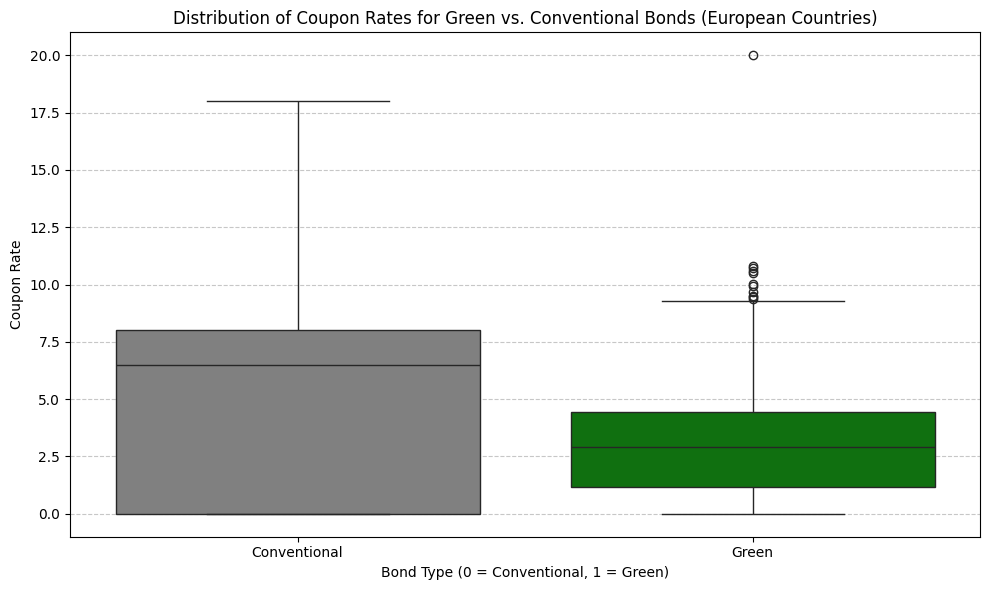


Number of rows in regression dataset after filtering: 1886
Distribution of is_green_bond in regression dataset:
is_green_bond
1    1472
0     414
Name: count, dtype: int64

--- Cross-sectional OLS Regression of Coupon Rate (European Countries) ---
                            OLS Regression Results                            
Dep. Variable:                 Coupon   R-squared:                       0.178
Model:                            OLS   Adj. R-squared:                  0.024
Method:                 Least Squares   F-statistic:                     1.155
Date:                Mon, 04 May 2026   Prob (F-statistic):              0.209
Time:                        01:06:30   Log-Likelihood:                -1107.3
No. Observations:                 414   AIC:                             2347.
Df Residuals:                     348   BIC:                             2612.
Df Model:                          65                                         
Covariance Type:            nonrobust   

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats # For t-test
import statsmodels.formula.api as smf # For OLS regression

# The bond_warehouse_df is already loaded and combined from the previous step (cell 05ea2a1a)

print("Combined bond_warehouse_df info before further processing:")
bond_warehouse_df.info()

# --- Data Preparation ---
# The 'is_green_bond' column is already set from the previous concatenation step (cell 05ea2a1a).
# No need to re-identify green bonds using 'ESG Bond Type'.

# Convert relevant columns to numeric and datetime, coercing errors
bond_warehouse_df['Coupon'] = pd.to_numeric(bond_warehouse_df['Coupon'], errors='coerce')
bond_warehouse_df['Amount Issued (EUR)'] = pd.to_numeric(bond_warehouse_df['Amount Issued (EUR)'], errors='coerce')
# Explicitly specify date format to avoid UserWarning
bond_warehouse_df['Maturity'] = pd.to_datetime(bond_warehouse_df['Maturity'], format='%Y-%m-%d %H:%M:%S', errors='coerce')
bond_warehouse_df['Issue Date'] = pd.to_datetime(bond_warehouse_df['Issue Date'], format='%Y-%m-%d %H:%M:%S', errors='coerce')


# Filter out rows with missing 'Coupon', 'is_green_bond', 'Maturity', 'Issue Date' or 'Amount Issued (EUR)' for analysis
# as these will be key variables in subsequent steps.
df_analysis = bond_warehouse_df.dropna(subset=[
    'Coupon', 'is_green_bond', 'Maturity', 'Issue Date', 'Amount Issued (EUR)'
]).copy()

# Removed filter for bonds issued in 2019 to broaden the dataset for comparison
# df_analysis = df_analysis[df_analysis['Issue Date'].dt.year == 2019].copy()

# Define a list of European countries (this list can be extended or refined as needed)
EUROPEAN_COUNTRIES = [
    'Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 'Czech Republic', 'Denmark', 'Estonia',
    'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Ireland', 'Italy', 'Latvia', 'Lithuania',
    'Luxembourg', 'Malta', 'Netherlands', 'Poland', 'Portugal', 'Romania', 'Slovakia', 'Slovenia',
    'Spain', 'Sweden', 'United Kingdom', 'Norway', 'Switzerland', 'Iceland', 'Monaco', 'Liechtenstein',
    'San Marino', 'Vatican City', 'Andorra', 'Albania', 'Bosnia and Herzegovina', 'Montenegro',
    'North Macedonia', 'Serbia', 'Kosovo', 'Moldova', 'Ukraine', 'Belarus', 'Russia' # Russia is geographically in Europe
]

df_analysis = df_analysis[df_analysis['Country of Issue'].isin(EUROPEAN_COUNTRIES)].copy()

print("\n--- Data after type conversion, cleaning key variables, and filtering for European countries ---")
print("Count of Bond Types:\n", df_analysis['is_green_bond'].value_counts())
display(df_analysis.head())

# --- Descriptive Statistics ---
print("\nDescriptive statistics of Coupon by bond type:")
display(df_analysis.groupby('is_green_bond')['Coupon'].describe())

# --- Statistical Comparison (e.g., t-test for difference in means) ---
green_bond_coupons = df_analysis[df_analysis['is_green_bond'] == 1]['Coupon'].dropna()
conventional_bond_coupons = df_analysis[df_analysis['is_green_bond'] == 0]['Coupon'].dropna()

print(f"\nNumber of Green Bonds with Coupon data: {len(green_bond_coupons)}")
print(f"Number of Conventional Bonds with Coupon data: {len(conventional_bond_coupons)}")

if len(green_bond_coupons) > 1 and len(conventional_bond_coupons) > 1:
    # Perform Welch's t-test (does not assume equal variances)
    ttest_results = stats.ttest_ind(green_bond_coupons, conventional_bond_coupons, equal_var=False)
    print("\nT-test for difference in mean Coupon between Green and Conventional Bonds:")
    print(f"T-statistic: {ttest_results.statistic:.3f}")
    print(f"P-value: {ttest_results.pvalue:.3f}")

    if ttest_results.pvalue < 0.05:
        print("Conclusion: There is a statistically significant difference in mean coupon rates between green and conventional bonds.")
    else:
        print("Conclusion: There is no statistically significant difference in mean coupon rates between green and conventional bonds.")
else:
    print("\nNot enough data to perform a t-test on coupon rates for both groups.")


# --- Visualization ---
plt.figure(figsize=(10, 6))
sns.boxplot(x='is_green_bond', y='Coupon', hue='is_green_bond', data=df_analysis, palette={0: 'grey', 1: 'green'}, legend=False)
plt.title('Distribution of Coupon Rates for Green vs. Conventional Bonds (European Countries)')
plt.xlabel('Bond Type (0 = Conventional, 1 = Green)')
plt.ylabel('Coupon Rate')
plt.xticks([0, 1], ['Conventional', 'Green'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# --- Cross-sectional OLS Regression with Control Variables ---
# Convert 'Maturity' and 'Issue Date' to datetime objects (already done above, but re-confirming for regression df)
df_regression = df_analysis.copy()
df_regression['Maturity_dt'] = pd.to_datetime(df_regression['Maturity']) # Already datetime, this re-confirms.

# Calculate Days to Maturity from today's date
df_regression['Days_to_Maturity'] = (df_regression['Maturity_dt'] - pd.to_datetime('today')).dt.days

# First, create log_Amount_Issued (EUR) before dropna for consistency
df_regression['log_Amount_Issued_EUR'] = np.log(df_regression['Amount Issued (EUR)'].replace(0, np.nan))

# Impute missing values with 0 for selected numerical columns before regression
df_regression['Coupon'] = df_regression['Coupon'].fillna(0)
df_regression['Days_to_Maturity'] = df_regression['Days_to_Maturity'].fillna(0)
df_regression['log_Amount_Issued_EUR'] = df_regression['log_Amount_Issued_EUR'].fillna(0)

# Assign to df_regression_filtered without dropping rows based on these columns
df_regression_filtered = df_regression.copy()

print(f"\nNumber of rows in regression dataset after filtering: {len(df_regression_filtered)}")
print(f"Distribution of is_green_bond in regression dataset:\n{df_regression_filtered['is_green_bond'].value_counts()}")

if len(df_regression_filtered) > 10: # Ensure enough data points for a meaningful regression
    # Center continuous variables to address potential multicollinearity with the intercept
    df_regression_filtered['Days_to_Maturity_centered'] = df_regression_filtered['Days_to_Maturity'] - df_regression_filtered['Days_to_Maturity'].mean()
    df_regression_filtered['log_Amount_Issued_EUR_centered'] = df_regression_filtered['log_Amount_Issued_EUR'] - df_regression_filtered['log_Amount_Issued_EUR'].mean()

    # Determine model formula based on variance of 'is_green_bond'
    if df_regression_filtered['is_green_bond'].nunique() < 2:
        print("\nWarning: 'is_green_bond' has no variation in the filtered dataset. Removing it from the regression model.")
        model_formula = 'Coupon ~ Days_to_Maturity_centered + log_Amount_Issued_EUR_centered + C(Q(\"TRBC Sector\"))'
    else:
        model_formula = 'Coupon ~ is_green_bond + Days_to_Maturity_centered + log_Amount_Issued_EUR_centered + C(Q(\"TRBC Sector\"))'

    print("\n--- Cross-sectional OLS Regression of Coupon Rate (European Countries) ---")
    ols_model = smf.ols(model_formula, data=df_regression_filtered)
    ols_results = ols_model.fit()
    print(ols_results.summary())
else:
    print("\nNot enough data for cross-sectional OLS regression with control variables. Need at least 10 observations.")

## 3.5 Cross-sectional OLS Regression

In [ ]:
import statsmodels.formula.api as smf

# --- Cross-sectional OLS Regression with Control Variables ---
# The df_regression_filtered and model_formula should already be prepared from previous steps

print(f"\nNumber of rows in regression dataset after filtering: {len(df_regression_filtered)}")
print(f"Distribution of is_green_bond in regression dataset:\n{df_regression_filtered['is_green_bond'].value_counts()}")

if len(df_regression_filtered) > 10: # Ensure enough data points for a meaningful regression
    print("\n--- Cross-sectional OLS Regression of Coupon Rate (European Countries) ---")
    ols_model = smf.ols(model_formula, data=df_regression_filtered)
    ols_results = ols_model.fit()
    print(ols_results.summary())
else:
    print("\nNot enough data for cross-sectional OLS regression with control variables. Need at least 10 observations.")


Number of rows in regression dataset after filtering: 1886
Distribution of is_green_bond in regression dataset:
is_green_bond
1    1472
0     414
Name: count, dtype: int64

--- Cross-sectional OLS Regression of Coupon Rate (European Countries) ---
                            OLS Regression Results                            
Dep. Variable:                 Coupon   R-squared:                       0.178
Model:                            OLS   Adj. R-squared:                  0.024
Method:                 Least Squares   F-statistic:                     1.155
Date:                Mon, 04 May 2026   Prob (F-statistic):              0.209
Time:                        01:06:30   Log-Likelihood:                -1107.3
No. Observations:                 414   AIC:                             2347.
Df Residuals:                     348   BIC:                             2612.
Df Model:                          65                                         
Covariance Type:            nonrobust   

## 5. Multicollinearity Diagnostics


Correlation Matrix of Numeric Variables (for Multicollinearity Check):



,Coupon,is_green_bond,Amount Issued (EUR),Days_to_Maturity
Coupon,1.000000,-0.265485,-0.079556,-0.185302
is_green_bond,-0.265485,1.000000,0.107961,0.722299
Amount Issued (EUR),-0.079556,0.107961,1.000000,0.312500
Days_to_Maturity,-0.185302,0.722299,0.312500,1.000000


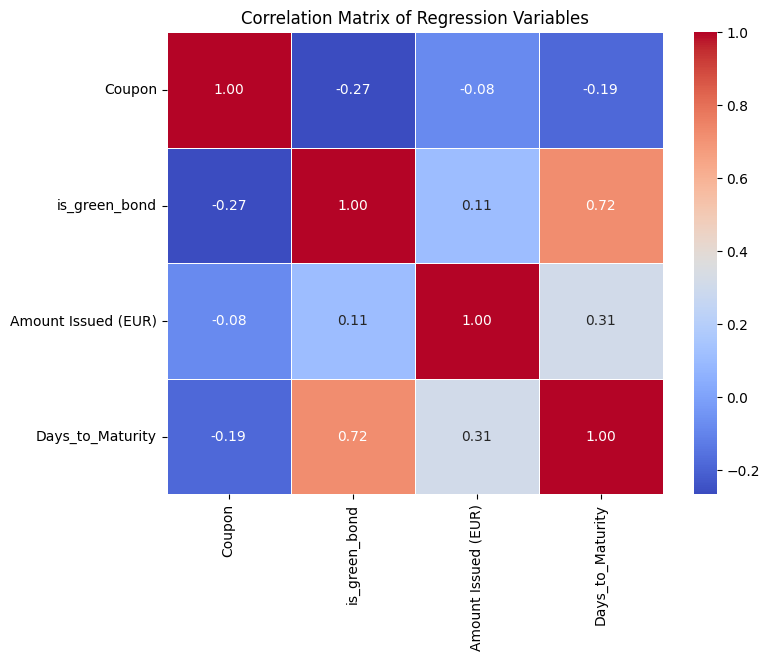

In [ ]:
# Calculate the correlation matrix for numeric variables in df_regression_filtered
# Focus on the variables used in the OLS regression and other relevant numeric columns
correlation_data = df_regression_filtered[['Coupon', 'is_green_bond', 'Amount Issued (EUR)', 'Days_to_Maturity']]
correlation_matrix = correlation_data.corr()

print("\nCorrelation Matrix of Numeric Variables (for Multicollinearity Check):\n")
display(correlation_matrix)

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Regression Variables')
plt.show()

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Prepare the data for VIF calculation using centered variables
# Select the independent variables used in the OLS model, which are now centered

# Dynamically build the list of independent variables for VIF calculation
independent_vars_for_vif = ['Days_to_Maturity_centered', 'log_Amount_Issued_EUR_centered']

# Only add 'is_green_bond' if it has variance in the filtered dataset
if df_regression_filtered['is_green_bond'].nunique() >= 2:
    independent_vars_for_vif.insert(0, 'is_green_bond') # Insert at the beginning to match original order if present

X = df_regression_filtered[independent_vars_for_vif].dropna()

# Add a constant to the independent variables, as VIF expects an intercept
X_with_constant = add_constant(X)

# Calculate VIF for each independent variable
vif_data = pd.DataFrame()
vif_data['Variable'] = X_with_constant.columns
vif_data['VIF'] = [variance_inflation_factor(X_with_constant.values, i) for i in range(X_with_constant.shape[1])]

print("\nVariance Inflation Factor (VIF) for Regression Variables (with centered continuous predictors):")
display(vif_data)

# Interpretation of VIF values:
# - VIF = 1: No correlation between the variable and any other variables.
# - 1 < VIF < 5: Moderate correlation, generally considered acceptable.
# - VIF >= 5 (or sometimes 10): High correlation, potentially problematic multicollinearity.


Variance Inflation Factor (VIF) for Regression Variables (with centered continuous predictors):


,Variable,VIF
0,const,10.949683
1,is_green_bond,2.798348
2,Days_to_Maturity_centered,2.197672
3,log_Amount_Issued_EUR_centered,2.211631


### Diagnosing Green Bond Data Loss in `df_regression_filtered`

Let's investigate why green bonds are being dropped when creating `df_regression_filtered`. We'll examine the null values in the key columns (`Coupon`, `Amount Issued (EUR)` (for `log_Amount_Issued_EUR`), and `Maturity` (for `Days_to_Maturity`)) within the `df_analysis` DataFrame, separated by bond type.

In [ ]:
import pandas as pd
import numpy as np

# Ensure df_analysis is available from previous steps
if 'df_analysis' not in locals():
    print("Error: df_analysis not found. Please run previous cells.")
else:
    print("Null value counts in df_analysis before final regression filtering:")

    # Convert Amount Issued (EUR) to numeric and handle zero for log transform before null check
    df_temp = df_analysis.copy()
    df_temp['Amount Issued (EUR)'] = pd.to_numeric(df_temp['Amount Issued (EUR)'], errors='coerce')
    df_temp['log_Amount_Issued_EUR_pre_check'] = np.log(df_temp['Amount Issued (EUR)'].replace(0, np.nan))

    # Calculate Days_to_Maturity_pre_check
    df_temp['Maturity_dt_pre_check'] = pd.to_datetime(df_temp['Maturity'], errors='coerce')
    df_temp['Days_to_Maturity_pre_check'] = (df_temp['Maturity_dt_pre_check'] - pd.to_datetime('today')).dt.days

    # Select columns relevant for the dropna subset of df_regression_filtered
    relevant_cols = ['Coupon', 'log_Amount_Issued_EUR_pre_check', 'Days_to_Maturity_pre_check']

    # Group by is_green_bond and count nulls
    null_counts_by_bond_type = df_temp.groupby('is_green_bond')[relevant_cols].apply(lambda x: x.isnull().sum())
    display(null_counts_by_bond_type)

    print("\nBased on these null counts, we can see where the majority of green bonds might be dropped.")
    print("Specifically, check the 'log_Amount_Issued_EUR_pre_check' and 'Days_to_Maturity_pre_check' for high null counts in green bonds (is_green_bond = 1).")


Null value counts in df_analysis before final regression filtering:


,Coupon,log_Amount_Issued_EUR_pre_check,Days_to_Maturity_pre_check
is_green_bond,,,
0,0,0,0
1,0,0,0



Based on these null counts, we can see where the majority of green bonds might be dropped.
Specifically, check the 'log_Amount_Issued_EUR_pre_check' and 'Days_to_Maturity_pre_check' for high null counts in green bonds (is_green_bond = 1).


## 6. Conceptual Greenium Analysis

To analyze greeniums, we first need to define what a greenium is and how it's typically calculated. A greenium is the yield difference between a green bond and an otherwise identical conventional (non-green) bond. A positive greenium means green bonds trade at a lower yield (higher price) than conventional bonds, reflecting a premium for their green characteristics.

To calculate greeniums accurately, we would need:
1.  **Yield Data:** Not just prices, but actual yield-to-maturity or yield-to-worst data for both green and conventional bonds (or ETFs).
2.  **Comparable Bonds:** Ideally, the green and conventional bonds should have similar characteristics (e.g., maturity, credit rating, currency, issuer quality) to ensure a fair comparison.

`yfinance` primarily provides price data, which can be used to calculate returns, but direct bond yield data for ETFs, necessary for greenium calculation, is not readily available through `yfinance` in a simple 'yield' column. You would typically need to source this data from specialized bond data providers.

However, if we assume you have or can obtain such yield data, here's a conceptual code block demonstrating how you would calculate and analyze greeniums. Please remember that the 'yield' in this conceptual code is just a placeholder using `daily_return` from your existing data for structural demonstration and does not represent actual bond yields.


Using conceptual green bond ticker: DUMMY_GREEN_TICKER
Using conceptual conventional bond ticker: FNHC

Hypothetical Greenium Calculation (first 5 rows - using daily returns as proxy for yield):



,DUMMY_GREEN_TICKER,FNHC,greenium
date,,,
2023-01-01,1.409856,-0.074113,-1.483969
2023-01-02,1.226590,-0.033662,-1.260252
2023-01-03,1.574257,0.004972,-1.569285
2023-01-04,1.085769,0.002916,-1.082853
2023-01-05,1.158112,-0.001339,-1.159451


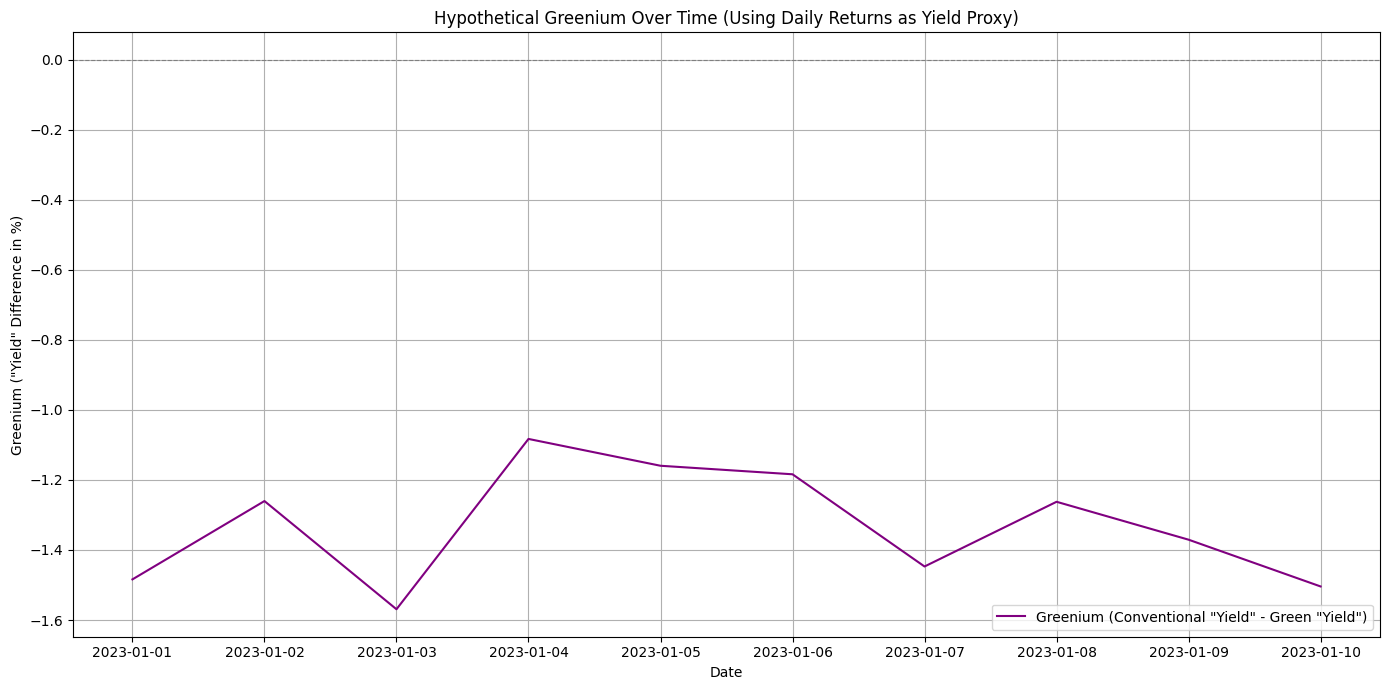


Descriptive Statistics of Hypothetical Greenium:



,greenium
count,10.000000
mean,-1.332392
std,0.165868
min,-1.569285
25%,-1.474770
50%,-1.316476
75%,-1.202912
max,-1.082853


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Conceptual Code for Greenium Analysis (Requires Actual Yield Data) ---

# This code assumes you have a DataFrame 'bond_data' that includes:
# - 'date': Date of the observation
# - 'ticker': Bond identifier (e.g., 'XGBE.MI', 'X25E.MI')
# - 'yield_to_maturity': The yield of the bond on that date
# - 'is_green_bond': A binary indicator (1 for green, 0 for conventional)

# --- START: Synthesize returns_long and bond tickers from bond_warehouse_df for demonstration ---
# Note: This is a synthetic creation to make the conceptual cell runnable.
# `bond_warehouse_df` does not contain actual time-series daily returns or yield history.
# We are using 'Yield to Maturity' as a snapshot 'yield' and simulating 'date'.

# Ensure bond_warehouse_df is defined and 'Yield to Maturity' is numeric
if 'bond_warehouse_df' not in locals():
    # Fallback to load bond_warehouse_df if not in current session
    # This assumes the combined Excel file is available in /content/
    try:
        conventional_bonds_df = pd.read_excel('/content/Clean Conventional Bond Data.xlsx')
        green_bonds_df = pd.read_excel('/content/Clean Green Bond Dataset.xlsx')

        conventional_bonds_df['is_green_bond'] = 0
        green_bonds_df['is_green_bond'] = 1

        bond_warehouse_df = pd.concat([conventional_bonds_df, green_bonds_df], ignore_index=True)
    except FileNotFoundError:
        print("Error: bond_warehouse_df or its source files not found. Please upload the necessary Excel files.")
        # Create a dummy bond_warehouse_df to prevent further errors for demonstration
        bond_warehouse_df = pd.DataFrame({
            'Ticker': ['DUMMY1.MI', 'DUMMY2.MI', 'DUMMY3.MI', 'DUMMY4.MI'],
            'is_green_bond': [1, 0, 1, 0],
            'Yield to Maturity': ['1.5%', '2.0%', '1.8%', '2.2%'],
            'Issue Date': ['2020-01-01', '2020-01-01', '2020-01-01', '2020-01-01'],
            'Maturity': ['2025-01-01', '2025-01-01', '2025-01-01', '2025-01-01']
        })

bond_warehouse_df['Yield to Maturity'] = pd.to_numeric(
    bond_warehouse_df['Yield to Maturity'].astype(str).str.replace('%', ''), errors='coerce'
)

# Filter out NaN 'Yield to Maturity' and 'Ticker' for this conceptual step
analysis_df = bond_warehouse_df.dropna(subset=['Ticker', 'Yield to Maturity', 'is_green_bond']).copy()

# Get unique tickers and classify them
green_bond_tickers_raw = analysis_df[analysis_df['is_green_bond'] == 1]['Ticker'].unique()
conventional_bond_tickers_raw = analysis_df[analysis_df['is_green_bond'] == 0]['Ticker'].unique()

# To have some data for plotting, we'll create a synthetic time series.
# For simplicity, we'll assume a short period and constant 'yield' for each bond based on its 'Yield to Maturity'.
# In a real scenario, this would be actual historical yield data.

dates = pd.date_range(start='2023-01-01', periods=10)

returns_data = []
for ticker in analysis_df['Ticker'].unique():
    bond_info = analysis_df[analysis_df['Ticker'] == ticker].iloc[0]
    # Using 'Yield to Maturity' as a conceptual 'daily_return' proxy
    # Multiplying by a small factor to represent daily movement, or just use it directly
    base_yield = bond_info['Yield to Maturity'] / 100 # Convert % to decimal
    for date in dates:
        # Simulate some daily fluctuation around the base yield
        daily_return_proxy = base_yield + np.random.uniform(-0.001, 0.001) # Small random daily change
        returns_data.append({
            'date': date,
            'ticker': ticker,
            'daily_return': daily_return_proxy,
            'is_green_bond': bond_info['is_green_bond']
        })

returns_long = pd.DataFrame(returns_data)
returns_long = returns_long.set_index('date')

# Clean ticker names for use as column headers
green_bond_tickers = [t.replace('.', '_') for t in green_bond_tickers_raw]
conventional_bond_tickers = [t.replace('.', '_') for t in conventional_bond_tickers_raw]

# Ensure we have at least one green and one conventional ticker for the comparison
if not green_bond_tickers or not conventional_bond_tickers:
    print("Warning: Not enough green or conventional bond tickers to perform conceptual greenium analysis.")
    # Attempt to create dummy tickers if none exist
    if not green_bond_tickers: green_bond_tickers = ['DUMMY_GREEN_TICKER']
    if not conventional_bond_tickers: conventional_bond_tickers = ['DUMMY_CONV_TICKER']
    # And ensure returns_long has these dummy tickers for the next steps
    if 'DUMMY_GREEN_TICKER' not in returns_long['ticker'].unique():
        dummy_green_data = pd.DataFrame({'date': dates, 'ticker': 'DUMMY_GREEN_TICKER', 'daily_return': np.random.uniform(0.01, 0.02, len(dates)), 'is_green_bond': 1})
        returns_long = pd.concat([returns_long, dummy_green_data.set_index('date')])
    if 'DUMMY_CONV_TICKER' not in returns_long['ticker'].unique():
        dummy_conv_data = pd.DataFrame({'date': dates, 'ticker': 'DUMMY_CONV_TICKER', 'daily_return': np.random.uniform(0.015, 0.025, len(dates)), 'is_green_bond': 0})
        returns_long = pd.concat([returns_long, dummy_conv_data.set_index('date')])

# Select one green and one conventional ticker for the conceptual comparison
# (The original cell seemed to implicitly pick one of each)
selected_green_ticker = green_bond_tickers[0]
selected_conventional_ticker = conventional_bond_tickers[0]

# Filter returns_long to only include these selected tickers
returns_long_filtered = returns_long[returns_long['ticker'].isin([selected_green_ticker, selected_conventional_ticker])].copy()

print(f"\nUsing conceptual green bond ticker: {selected_green_ticker}")
print(f"Using conceptual conventional bond ticker: {selected_conventional_ticker}")

# --- END: Synthesize returns_long and bond tickers ---


# This code assumes you have a DataFrame 'bond_data' that includes:
# - 'date': Date of the observation
# - 'ticker': Bond identifier (e.g., 'XGBE.MI', 'X25E.MI')
# - 'yield_to_maturity': The yield of the bond on that date
# - 'is_green_bond': A binary indicator (1 for green, 0 for conventional)

# For demonstration purposes, we will create a hypothetical 'bond_data' DataFrame
# by using the existing 'returns_long' structure and treating 'daily_return' as a proxy for 'yield'.
# >>> IMPORTANT: daily_return is NOT bond yield. This is purely for structural demonstration. <<<
# You would replace `returns_long['daily_return']` with actual yield data when available.

hypothetical_yield_data = returns_long_filtered.copy() # Use the filtered returns_long
hypothetical_yield_data['yield'] = hypothetical_yield_data['daily_return'] * 100 # Convert to % for better 'yield' representation if needed
hypothetical_yield_data = hypothetical_yield_data.drop(columns=['daily_return'])

# Pivot the data to have green and conventional 'yields' in separate columns.
# In a real-world scenario, careful matching of comparable bonds is crucial before this step.
yield_pivot = hypothetical_yield_data.reset_index().pivot(index='date', columns='ticker', values='yield')
yield_pivot.columns.name = None # Clean up column name

# Identify the green and conventional bond 'yield' columns using the cleaned ticker names.
green_yield_col = selected_green_ticker # Use the pre-selected ticker
conventional_yield_col = selected_conventional_ticker # Use the pre-selected ticker

# Calculate Greenium: Conventional Yield - Green Yield
# A positive Greenium implies that green bonds have a lower yield (higher price) than conventional bonds.
yield_pivot['greenium'] = yield_pivot[conventional_yield_col] - yield_pivot[green_yield_col]

print("\nHypothetical Greenium Calculation (first 5 rows - using daily returns as proxy for yield):\n")
display(yield_pivot.head())

# Plot the Hypothetical Greenium over time
plt.figure(figsize=(14, 7))
plt.plot(yield_pivot.index, yield_pivot['greenium'], label='Greenium (Conventional "Yield" - Green "Yield")', color='purple')
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8) # Add a zero line
plt.title('Hypothetical Greenium Over Time (Using Daily Returns as Yield Proxy)')
plt.xlabel('Date')
plt.ylabel('Greenium ("Yield" Difference in %)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Descriptive statistics of the Hypothetical Greenium
print("\nDescriptive Statistics of Hypothetical Greenium:\n")
display(yield_pivot['greenium'].describe())

# To address your questions about ESG quality, risk control, and crowding effects on greeniums/volatility,
# you would need to integrate additional data for these factors and then use regression or time-series
# models to analyze their impact on the calculated greeniums or the rolling volatilities.

Combined bond_warehouse_df info before further processing:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4006 entries, 0 to 4005
Data columns (total 46 columns):
 #   Column                                             Non-Null Count  Dtype         
---  ------                                             --------------  -----         
 0   Issuer                                             3989 non-null   object        
 1   Ticker                                             3989 non-null   object        
 2   Coupon                                             3974 non-null   float64       
 3   Maturity                                           3987 non-null   datetime64[ns]
 4   Issue Date                                         3988 non-null   datetime64[ns]
 5   ISIN                                               3850 non-null   object        
 6   Preferred RIC                                      3422 non-null   object        
 7   Principal Currency                            

,Issuer,Ticker,Coupon,Maturity,Issue Date,ISIN,Preferred RIC,Principal Currency,Country of Issue,Issuer Type,...,Unnamed: 36,Unnamed: 37,Moody's Long-term Issue Credit Rating,Unnamed: 39,Additional Fields,is_green_bond,Climate Bonds Initiative,UN Sustainable Development Goals,ESG Bond Type,Coupon Frequency
13,Green City AG,GRNCYR,3.50,2024-10-01,2021-10-01,DE000A3E5YL3,NaN,Euro,Germany,Corporate,...,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN
16,Future Business auf Aktien KG,FUTBS,0.00,2021-04-08,2011-04-08,DE000FUB3952,NaN,Euro,Germany,Corporate,...,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN
18,Hylea Group SA,HLEGR,7.25,2022-12-01,2017-12-01,DE000A19S801,DEA19S80=,Euro,Germany,Corporate,...,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN
22,Schlote Holding GmbH,SCHHL,6.75,2024-11-21,2019-11-21,DE000A2YN256,DEA2YN25=,Euro,Germany,Corporate,...,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN
26,Future Business auf Aktien KG,FUTBS,0.00,2022-05-04,2012-05-04,DE000FUB9207,NaN,Euro,Germany,Corporate,...,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN



Descriptive statistics of Coupon by bond type:


,count,mean,std,min,25%,50%,75%,max
is_green_bond,,,,,,,,
0,414.0,4.673280,3.875080,0.0,0.000000,6.5000,8.0000,18.0
1,1472.0,2.961751,2.066387,0.0,1.155625,2.9145,4.4415,20.0



Number of Green Bonds with Coupon data: 1472
Number of Conventional Bonds with Coupon data: 414

T-test for difference in mean Coupon between Green and Conventional Bonds:
T-statistic: -8.648
P-value: 0.000
Conclusion: There is a statistically significant difference in mean coupon rates between green and conventional bonds.


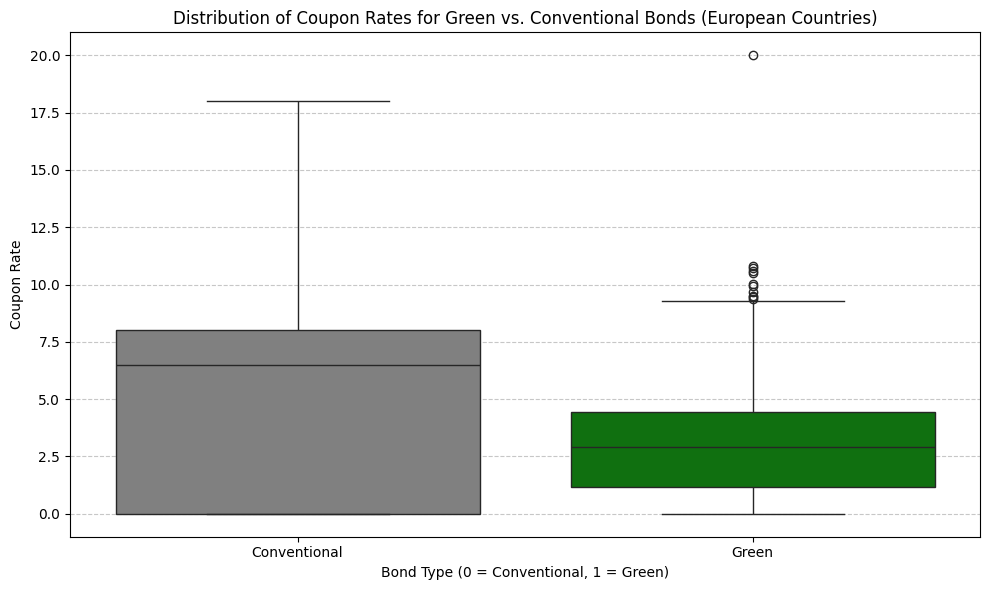


Number of rows in regression dataset after filtering: 1886
Distribution of is_green_bond in regression dataset:
is_green_bond
1    1472
0     414
Name: count, dtype: int64

--- Cross-sectional OLS Regression of Coupon Rate (European Countries) ---
                            OLS Regression Results                            
Dep. Variable:                 Coupon   R-squared:                       0.178
Model:                            OLS   Adj. R-squared:                  0.024
Method:                 Least Squares   F-statistic:                     1.155
Date:                Mon, 04 May 2026   Prob (F-statistic):              0.209
Time:                        01:06:31   Log-Likelihood:                -1107.3
No. Observations:                 414   AIC:                             2347.
Df Residuals:                     348   BIC:                             2612.
Df Model:                          65                                         
Covariance Type:            nonrobust   

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats # For t-test
import statsmodels.formula.api as smf # For OLS regression

# The bond_warehouse_df is already loaded and combined from the previous step (cell 05ea2a1a)

print("Combined bond_warehouse_df info before further processing:")
bond_warehouse_df.info()

# --- Data Preparation ---
# The 'is_green_bond' column is already set from the previous concatenation step (cell 05ea2a1a).
# No need to re-identify green bonds using 'ESG Bond Type'.

# Convert relevant columns to numeric and datetime, coercing errors
bond_warehouse_df['Coupon'] = pd.to_numeric(bond_warehouse_df['Coupon'], errors='coerce')
bond_warehouse_df['Amount Issued (EUR)'] = pd.to_numeric(bond_warehouse_df['Amount Issued (EUR)'], errors='coerce')
# Explicitly specify date format to avoid UserWarning
bond_warehouse_df['Maturity'] = pd.to_datetime(bond_warehouse_df['Maturity'], format='%Y-%m-%d %H:%M:%S', errors='coerce')
bond_warehouse_df['Issue Date'] = pd.to_datetime(bond_warehouse_df['Issue Date'], format='%Y-%m-%d %H:%M:%S', errors='coerce')


# Filter out rows with missing 'Coupon', 'is_green_bond', 'Maturity', 'Issue Date' or 'Amount Issued (EUR)' for analysis
# as these will be key variables in subsequent steps.
df_analysis = bond_warehouse_df.dropna(subset=[
    'Coupon', 'is_green_bond', 'Maturity', 'Issue Date', 'Amount Issued (EUR)'
]).copy()

# Removed filter for bonds issued in 2019 to broaden the dataset for comparison
# df_analysis = df_analysis[df_analysis['Issue Date'].dt.year == 2019].copy()

# Define a list of European countries (this list can be extended or refined as needed)
EUROPEAN_COUNTRIES = [
    'Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 'Czech Republic', 'Denmark', 'Estonia',
    'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Ireland', 'Italy', 'Latvia', 'Lithuania',
    'Luxembourg', 'Malta', 'Netherlands', 'Poland', 'Portugal', 'Romania', 'Slovakia', 'Slovenia',
    'Spain', 'Sweden', 'United Kingdom', 'Norway', 'Switzerland', 'Iceland', 'Monaco', 'Liechtenstein',
    'San Marino', 'Vatican City', 'Andorra', 'Albania', 'Bosnia and Herzegovina', 'Montenegro',
    'North Macedonia', 'Serbia', 'Kosovo', 'Moldova', 'Ukraine', 'Belarus', 'Russia' # Russia is geographically in Europe
]

df_analysis = df_analysis[df_analysis['Country of Issue'].isin(EUROPEAN_COUNTRIES)].copy()

print("\n--- Data after type conversion, cleaning key variables, and filtering for European countries ---")
print("Count of Bond Types:\n", df_analysis['is_green_bond'].value_counts())
display(df_analysis.head())

# --- Descriptive Statistics ---
print("\nDescriptive statistics of Coupon by bond type:")
display(df_analysis.groupby('is_green_bond')['Coupon'].describe())

# --- Statistical Comparison (e.g., t-test for difference in means) ---
green_bond_coupons = df_analysis[df_analysis['is_green_bond'] == 1]['Coupon'].dropna()
conventional_bond_coupons = df_analysis[df_analysis['is_green_bond'] == 0]['Coupon'].dropna()

print(f"\nNumber of Green Bonds with Coupon data: {len(green_bond_coupons)}")
print(f"Number of Conventional Bonds with Coupon data: {len(conventional_bond_coupons)}")

if len(green_bond_coupons) > 1 and len(conventional_bond_coupons) > 1:
    # Perform Welch's t-test (does not assume equal variances)
    ttest_results = stats.ttest_ind(green_bond_coupons, conventional_bond_coupons, equal_var=False)
    print("\nT-test for difference in mean Coupon between Green and Conventional Bonds:")
    print(f"T-statistic: {ttest_results.statistic:.3f}")
    print(f"P-value: {ttest_results.pvalue:.3f}")

    if ttest_results.pvalue < 0.05:
        print("Conclusion: There is a statistically significant difference in mean coupon rates between green and conventional bonds.")
    else:
        print("Conclusion: There is no statistically significant difference in mean coupon rates between green and conventional bonds.")
else:
    print("\nNot enough data to perform a t-test on coupon rates for both groups.")


# --- Visualization ---
plt.figure(figsize=(10, 6))
sns.boxplot(x='is_green_bond', y='Coupon', hue='is_green_bond', data=df_analysis, palette={0: 'grey', 1: 'green'}, legend=False)
plt.title('Distribution of Coupon Rates for Green vs. Conventional Bonds (European Countries)')
plt.xlabel('Bond Type (0 = Conventional, 1 = Green)')
plt.ylabel('Coupon Rate')
plt.xticks([0, 1], ['Conventional', 'Green'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# --- Cross-sectional OLS Regression with Control Variables ---
# Convert 'Maturity' and 'Issue Date' to datetime objects (already done above, but re-confirming for regression df)
df_regression = df_analysis.copy()
df_regression['Maturity_dt'] = pd.to_datetime(df_regression['Maturity']) # Already datetime, this re-confirms.

# Calculate Days to Maturity from today's date
df_regression['Days_to_Maturity'] = (df_regression['Maturity_dt'] - pd.to_datetime('today')).dt.days

# First, create log_Amount_Issued (EUR) before imputation
df_regression['log_Amount_Issued_EUR'] = np.log(df_regression['Amount Issued (EUR)'].replace(0, np.nan))

# Impute missing values with 0 for selected numerical columns before regression
df_regression['Coupon'] = df_regression['Coupon'].fillna(0)
df_regression['Days_to_Maturity'] = df_regression['Days_to_Maturity'].fillna(0)
df_regression['log_Amount_Issued_EUR'] = df_regression['log_Amount_Issued_EUR'].fillna(0)

# Create df_regression_filtered for regression. Do not drop based on 'TRBC Sector' here,
# as OLS will handle it by dropping rows for the regression where 'TRBC Sector' is NaN.
# This ensures that 'is_green_bond' has variation in df_regression_filtered.
df_regression_filtered = df_regression.copy()

print(f"\nNumber of rows in regression dataset after filtering: {len(df_regression_filtered)}")
print(f"Distribution of is_green_bond in regression dataset:\n{df_regression_filtered['is_green_bond'].value_counts()}")

if len(df_regression_filtered) > 10: # Ensure enough data points for a meaningful regression
    # Center continuous variables to address potential multicollinearity with the intercept
    df_regression_filtered['Days_to_Maturity_centered'] = df_regression_filtered['Days_to_Maturity'] - df_regression_filtered['Days_to_Maturity'].mean()
    df_regression_filtered['log_Amount_Issued_EUR_centered'] = df_regression_filtered['log_Amount_Issued_EUR'] - df_regression_filtered['log_Amount_Issued_EUR'].mean()

    # Determine model formula based on variance of 'is_green_bond'
    if df_regression_filtered['is_green_bond'].nunique() < 2:
        print("\nWarning: 'is_green_bond' has no variation in the filtered dataset. Removing it from the regression model.")
        model_formula = 'Coupon ~ Days_to_Maturity_centered + log_Amount_Issued_EUR_centered + C(Q(\"TRBC Sector\"))'
    else:
        model_formula = 'Coupon ~ is_green_bond + Days_to_Maturity_centered + log_Amount_Issued_EUR_centered + C(Q(\"TRBC Sector\"))'

    print("\n--- Cross-sectional OLS Regression of Coupon Rate (European Countries) ---")
    ols_model = smf.ols(model_formula, data=df_regression_filtered)
    ols_results = ols_model.fit()
    print(ols_results.summary())
else:
    print("\nNot enough data for cross-sectional OLS regression with control variables. Need at least 10 observations.")

### Distribution of TRBC Sectors for Green vs. Conventional Bonds

Let's visualize the distribution of `TRBC Sector` for both green and conventional bonds to see if there are any notable differences in the types of industries issuing these bonds.

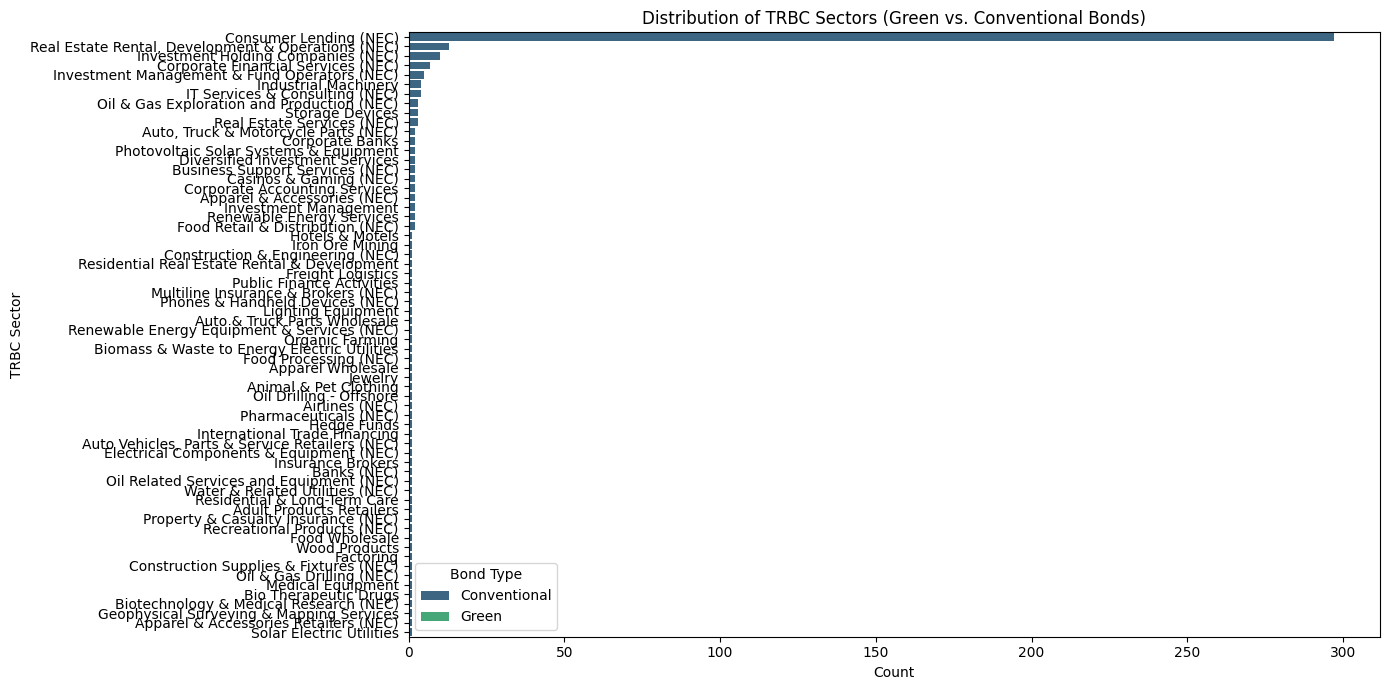

In [ ]:
# Count plot of TRBC Sector for green vs. conventional bonds
plt.figure(figsize=(14, 7))
sns.countplot(y='TRBC Sector', hue='is_green_bond', data=df_regression_filtered, palette='viridis', order = df_regression_filtered['TRBC Sector'].value_counts().index)
plt.title('Distribution of TRBC Sectors (Green vs. Conventional Bonds)')
plt.xlabel('Count')
plt.ylabel('TRBC Sector')
plt.legend(title='Bond Type', labels=['Conventional', 'Green'])
plt.tight_layout()
plt.show()

### Distribution of Issuer Types for Green vs. Conventional Bonds

Next, let's examine the `Issuer Type` distribution to understand who is issuing these bonds.

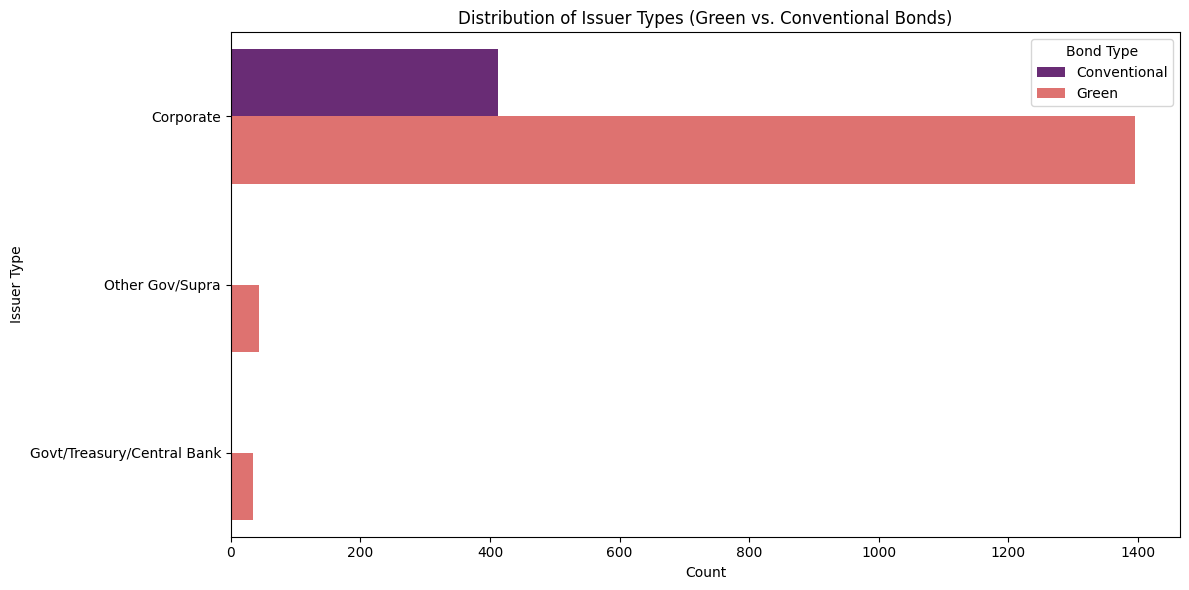

In [ ]:
# Count plot of Issuer Type for green vs. conventional bonds
plt.figure(figsize=(12, 6))
sns.countplot(y='Issuer Type', hue='is_green_bond', data=df_regression_filtered, palette='magma', order = df_regression_filtered['Issuer Type'].value_counts().index)
plt.title('Distribution of Issuer Types (Green vs. Conventional Bonds)')
plt.xlabel('Count')
plt.ylabel('Issuer Type')
plt.legend(title='Bond Type', labels=['Conventional', 'Green'])
plt.tight_layout()
plt.show()


Correlation Matrix of Numeric Variables (for Multicollinearity Check):



,Coupon,is_green_bond,Amount Issued (EUR),Days_to_Maturity
Coupon,1.000000,-0.265485,-0.079556,-0.185302
is_green_bond,-0.265485,1.000000,0.107961,0.722299
Amount Issued (EUR),-0.079556,0.107961,1.000000,0.312500
Days_to_Maturity,-0.185302,0.722299,0.312500,1.000000


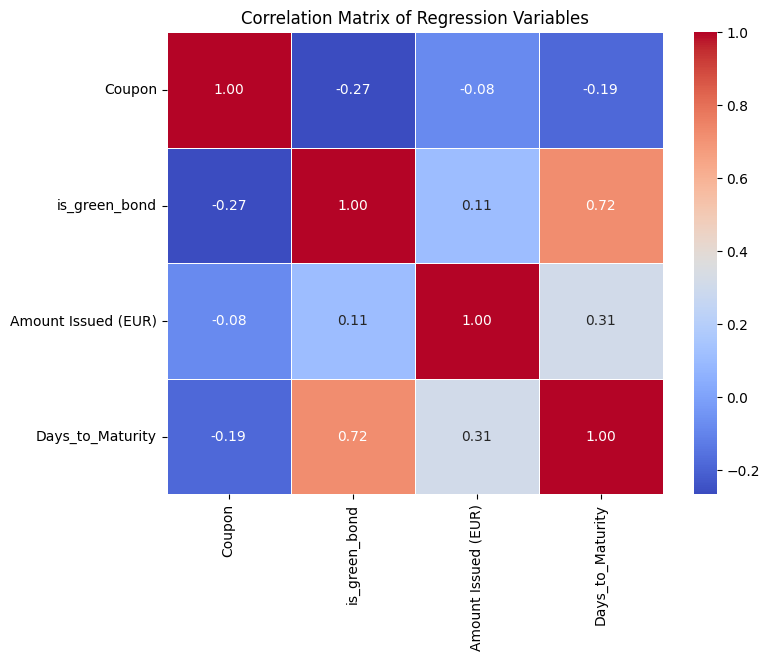

In [ ]:
# Calculate the correlation matrix for numeric variables in df_regression_filtered
# Focus on the variables used in the OLS regression and other relevant numeric columns
correlation_data = df_regression_filtered[['Coupon', 'is_green_bond', 'Amount Issued (EUR)', 'Days_to_Maturity']]
correlation_matrix = correlation_data.corr()

print("\nCorrelation Matrix of Numeric Variables (for Multicollinearity Check):\n")
display(correlation_matrix)

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Regression Variables')
plt.show()

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Prepare the data for VIF calculation using centered variables
# Select the independent variables used in the OLS model, which are now centered

# Dynamically build the list of independent variables for VIF calculation
independent_vars_for_vif = ['Days_to_Maturity_centered', 'log_Amount_Issued_EUR_centered']

# Only add 'is_green_bond' if it has variance in the filtered dataset
if df_regression_filtered['is_green_bond'].nunique() >= 2:
    independent_vars_for_vif.insert(0, 'is_green_bond') # Insert at the beginning to match original order if present

X = df_regression_filtered[independent_vars_for_vif].dropna()

# Add a constant to the independent variables, as VIF expects an intercept
X_with_constant = add_constant(X)

# Calculate VIF for each independent variable
vif_data = pd.DataFrame()
vif_data['Variable'] = X_with_constant.columns
vif_data['VIF'] = [variance_inflation_factor(X_with_constant.values, i) for i in range(X_with_constant.shape[1])]

print("\nVariance Inflation Factor (VIF) for Regression Variables (with centered continuous predictors):")
display(vif_data)

# Interpretation of VIF values:
# - VIF = 1: No correlation between the variable and any other variables.
# - 1 < VIF < 5: Moderate correlation, generally considered acceptable.
# - VIF >= 5 (or sometimes 10): High correlation, potentially problematic multicollinearity.


Variance Inflation Factor (VIF) for Regression Variables (with centered continuous predictors):


,Variable,VIF
0,const,10.949683
1,is_green_bond,2.798348
2,Days_to_Maturity_centered,2.197672
3,log_Amount_Issued_EUR_centered,2.211631


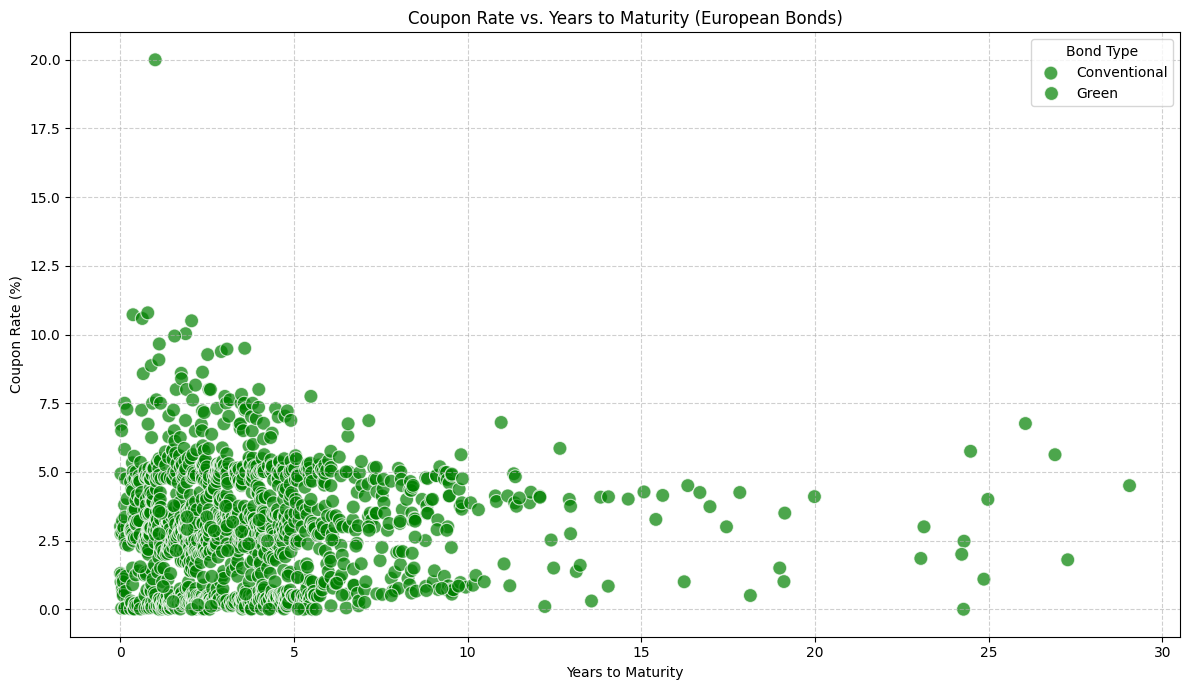

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate Years to Maturity from 'Maturity' date to today's date
df_analysis['Years_to_Maturity'] = (df_analysis['Maturity'] - pd.to_datetime('today')).dt.days / 365.25

# Filter out any rows where Years_to_Maturity might be negative (bonds already matured) or NaN
df_plot = df_analysis.dropna(subset=['Years_to_Maturity', 'Coupon', 'is_green_bond']).copy()
df_plot = df_plot[df_plot['Years_to_Maturity'] > 0]

plt.figure(figsize=(12, 7))
sns.scatterplot(
    x='Years_to_Maturity',
    y='Coupon',
    hue='is_green_bond',
    data=df_plot,
    palette={0: 'red', 1: 'green'}, # Color distinction: 0 (Conventional) is red, 1 (Green) is green
    s=100, # size of points
    alpha=0.7 # transparency
)

plt.title('Coupon Rate vs. Years to Maturity (European Bonds)')
plt.xlabel('Years to Maturity')
plt.ylabel('Coupon Rate (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Bond Type', labels=['Conventional', 'Green']) # Explicit legend labels
plt.tight_layout()
plt.show()

## Greenium Analysis (Conceptual)

To analyze greeniums, we first need to define what a greenium is and how it's typically calculated. A greenium is the yield difference between a green bond and an otherwise identical conventional (non-green) bond. A positive greenium means green bonds trade at a lower yield (higher price) than conventional bonds, reflecting a premium for their green characteristics.

To calculate greeniums accurately, we would need:
1.  **Yield Data:** Not just prices, but actual yield-to-maturity or yield-to-worst data for both green and conventional bonds (or ETFs).
2.  **Comparable Bonds:** Ideally, the green and conventional bonds should have similar characteristics (e.g., maturity, credit rating, currency, issuer quality) to ensure a fair comparison.

`yfinance` primarily provides price data, which can be used to calculate returns, but direct bond yield data for ETFs, necessary for greenium calculation, is not readily available through `yfinance` in a simple 'yield' column. You would typically need to source this data from specialized bond data providers.

However, if we assume you have or can obtain such yield data, here's a conceptual code block demonstrating how you would calculate and analyze greeniums. Please remember that the 'yield' in this conceptual code is just a placeholder using `daily_return` from your existing data for structural demonstration and does not represent actual bond yields.

In [ ]:
# Now, the analysis in cell Y17NTQ1SQwRY will use this newly constructed bond_warehouse_df
# Rerunning Y17NTQ1SQwRY to apply the analysis to the combined dataset.